# NovaBank Predictive Retention at Scale

## Reproducible Analytical Pipeline

**Business objective:** Replace untargeted mass outreach with a targeted Top-20% customer-contact policy using predicted response probability.

**Analytical framing:** The supplied dataset does not contain a customer-churn outcome. Term-deposit subscription is therefore used as a proxy for proactive retention engagement.

**Decision rule:** Rank customers by predicted response probability using pre-call information and target the highest-scoring 20%.

**Important modeling control:** `duration` is excluded because it is only known after the call and would introduce look-ahead leakage.

**Economic assumptions:** €15 per call and an illustrative €250 campaign value. These assumptions are not contained in the supplied dataset.

In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

TOP_FRACTION = 0.20
CALL_COST = 15.0
ASSUMED_CAMPAIGN_VALUE = 250.0
LOW_VALUE_CAMPAIGN_VALUE = 200.0
INTEREST_RATE_CONVERSION_SHOCK = 0.085
RANDOM_STATE = 42

## 1. Data Loading and Preparation

The analysis uses the supplied `bank-additional-full.csv` dataset containing 41,188 customer contacts.

The target is whether the customer subscribed to a term deposit.

`duration` is removed before modeling because it is measured after the call and would not be available for a pre-call targeting decision.

In [3]:
candidate_paths = [
    Path("data") / "bank-additional-full.csv",
    Path("bank-additional") / "bank-additional-full.csv",
    Path("bank-additional-full.csv"),
]

data_path = next(
    (p for p in candidate_paths if p.exists()),
    None
)

if data_path is None:
    raise FileNotFoundError(
        "Could not locate bank-additional-full.csv."
    )

df = pd.read_csv(data_path, sep=";")

if len(df) != 41188:
    raise ValueError(
        f"Expected 41,188 rows but found {len(df):,}."
    )

df["target"] = (
    df["y"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("yes")
).astype(int)

print(f"Dataset: {data_path}")
print(f"Rows: {len(df):,}")
print(f"Historical conversions: {df['target'].sum():,}")
print(f"Historical conversion rate: {df['target'].mean():.2%}")

raw_for_audit = df.copy()

df = df.drop(columns=["duration", "y"])

df["previously_contacted"] = (
    df["pdays"] != 999
).astype(int)

categorical_cols = (
    df.select_dtypes(
        include=["object", "str"]
    )
    .columns
    .tolist()
)

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

X = df_encoded.drop(columns=["target"])
y = df_encoded["target"]

print(f"Model features: {X.shape[1]}")

Dataset: data\bank-additional-full.csv
Rows: 41,188
Historical conversions: 4,640
Historical conversion rate: 11.27%
Model features: 53


In [4]:
# Stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Training observations: {len(X_train):,}")
print(f"Test observations: {len(X_test):,}")
print(f"Training conversion rate: {y_train.mean():.2%}")
print(f"Test conversion rate: {y_test.mean():.2%}")

Training observations: 32,950
Test observations: 8,238
Training conversion rate: 11.27%
Test conversion rate: 11.26%


In [5]:
# Baseline model: Logistic Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

baseline_model = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE
)

baseline_model.fit(X_train_scaled, y_train)


# Improved model: Gradient Boosting
improved_model = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_iter=200,
    max_leaf_nodes=15,
    l2_regularization=1.0,
    random_state=RANDOM_STATE
)

improved_model.fit(X_train, y_train)

print("Both models trained successfully.")

Both models trained successfully.


In [6]:
# Generate predicted probabilities on the test set
baseline_prob = baseline_model.predict_proba(X_test_scaled)[:, 1]
improved_prob = improved_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")
print(f"Baseline probability range: {baseline_prob.min():.4f} - {baseline_prob.max():.4f}")
print(f"Improved probability range: {improved_prob.min():.4f} - {improved_prob.max():.4f}")

Predictions generated successfully.
Baseline probability range: 0.0054 - 0.9018
Improved probability range: 0.0100 - 0.8893


In [7]:
# Model performance
baseline_auc = roc_auc_score(y_test, baseline_prob)
improved_auc = roc_auc_score(y_test, improved_prob)

baseline_brier = brier_score_loss(y_test, baseline_prob)
improved_brier = brier_score_loss(y_test, improved_prob)

def top_fraction_metrics(y_true, probabilities, fraction=0.20):
    n_top = int(len(y_true) * fraction)
    ranking = np.argsort(probabilities)[::-1]
    top_idx = ranking[:n_top]

    top_actuals = np.asarray(y_true)[top_idx]
    precision = top_actuals.mean()
    recall = top_actuals.sum() / np.asarray(y_true).sum()
    lift = precision / np.asarray(y_true).mean()

    return precision, recall, lift, top_actuals.sum()

baseline_precision, baseline_recall, baseline_lift, baseline_conversions = (
    top_fraction_metrics(y_test, baseline_prob, TOP_FRACTION)
)

improved_precision, improved_recall, improved_lift, improved_conversions = (
    top_fraction_metrics(y_test, improved_prob, TOP_FRACTION)
)

print("MODEL PERFORMANCE")
print(
    f"Logistic Regression | "
    f"ROC-AUC: {baseline_auc:.4f} | "
    f"Brier: {baseline_brier:.4f} | "
    f"Precision@20%: {baseline_precision:.2%} | "
    f"Recall: {baseline_recall:.2%} | "
    f"Lift: {baseline_lift:.2f}x"
)

print(
    f"Gradient Boosting | "
    f"ROC-AUC: {improved_auc:.4f} | "
    f"Brier: {improved_brier:.4f} | "
    f"Precision@20%: {improved_precision:.2%} | "
    f"Recall: {improved_recall:.2%} | "
    f"Lift: {improved_lift:.2f}x"
)

MODEL PERFORMANCE
Logistic Regression | ROC-AUC: 0.8008 | Brier: 0.0769 | Precision@20%: 36.67% | Recall: 65.09% | Lift: 3.26x
Gradient Boosting | ROC-AUC: 0.8142 | Brier: 0.0743 | Precision@20%: 37.77% | Recall: 67.03% | Lift: 3.35x


In [11]:
# Campaign economics under the Top-20% policy

n_total = len(df)
n_test = len(y_test)
scale_factor = n_total / n_test

legacy_conversions = int(round(y.mean() * n_total))
top20_contacts = int(round(n_total * TOP_FRACTION))

# Scale test-set results to the full campaign population
gb_top20_conversions = int(round(improved_conversions * scale_factor))
lr_top20_conversions = int(round(baseline_conversions * scale_factor))

legacy_profit = (
    legacy_conversions * ASSUMED_CAMPAIGN_VALUE
    - n_total * CALL_COST
)

gb_profit = (
    gb_top20_conversions * ASSUMED_CAMPAIGN_VALUE
    - top20_contacts * CALL_COST
)

lr_profit = (
    lr_top20_conversions * ASSUMED_CAMPAIGN_VALUE
    - top20_contacts * CALL_COST
)

gb_uplift = gb_profit - legacy_profit
gb_uplift_pct = gb_uplift / legacy_profit

gb_false_positives = top20_contacts - gb_top20_conversions
gb_false_negatives = legacy_conversions - gb_top20_conversions

gb_precision = gb_top20_conversions / top20_contacts
gb_recall = gb_top20_conversions / legacy_conversions

rocs = (
    gb_top20_conversions * ASSUMED_CAMPAIGN_VALUE
) / (
    top20_contacts * CALL_COST
)

print("CAMPAIGN ECONOMICS")
print(f"Legacy mass outreach profit: €{legacy_profit:,.0f}")
print(f"Logistic Regression top-20% profit: €{lr_profit:,.0f}")
print(f"Gradient Boosting top-20% profit: €{gb_profit:,.0f}")
print(f"Profit uplift vs. legacy: €{gb_uplift:,.0f} ({gb_uplift_pct:.1%})")
print(f"Top-20% contacts: {top20_contacts:,}")
print(f"Estimated conversions captured: {gb_top20_conversions:,}")
print(f"Estimated false positives: {gb_false_positives:,}")
print(f"Estimated false negatives: {gb_false_negatives:,}")
print(f"Precision@20%: {gb_precision:.2%}")
print(f"Conversion capture (Recall): {gb_recall:.2%}")
print(f"Return on Campaign Spend: {rocs:.2f}x")

CAMPAIGN ECONOMICS
Legacy mass outreach profit: €542,180
Logistic Regression top-20% profit: €631,430
Gradient Boosting top-20% profit: €653,930
Profit uplift vs. legacy: €111,750 (20.6%)
Top-20% contacts: 8,238
Estimated conversions captured: 3,110
Estimated false positives: 5,128
Estimated false negatives: 1,530
Precision@20%: 37.75%
Conversion capture (Recall): 67.03%
Return on Campaign Spend: 6.29x


In [12]:
# Sensitivity to lower campaign value

mass_profit_200 = (
    legacy_conversions * LOW_VALUE_CAMPAIGN_VALUE
    - n_total * CALL_COST
)

top20_profit_200 = (
    gb_top20_conversions * LOW_VALUE_CAMPAIGN_VALUE
    - top20_contacts * CALL_COST
)

print("€200 CAMPAIGN-VALUE SCENARIO")
print(f"Mass outreach: €{mass_profit_200:,.0f}")
print(f"Top-20% policy: €{top20_profit_200:,.0f}")
print(
    f"Top-20% advantage: "
    f"€{top20_profit_200 - mass_profit_200:,.0f}"
)

€200 CAMPAIGN-VALUE SCENARIO
Mass outreach: €310,180
Top-20% policy: €498,430
Top-20% advantage: €188,250


In [13]:
# Illustrative interest-rate sensitivity

stressed_conversions = int(
    round(gb_top20_conversions * (1 - INTEREST_RATE_CONVERSION_SHOCK))
)

stressed_profit = (
    stressed_conversions * ASSUMED_CAMPAIGN_VALUE
    - top20_contacts * CALL_COST
)

print("INTEREST-RATE SENSITIVITY")
print(
    "Illustrative scenario: 100 bps reduction corresponds "
    "to an 8.5% conversion reduction."
)
print(f"Stressed conversions: {stressed_conversions:,}")
print(f"Stressed top-20% profit: €{stressed_profit:,.0f}")

INTEREST-RATE SENSITIVITY
Illustrative scenario: 100 bps reduction corresponds to an 8.5% conversion reduction.
Stressed conversions: 2,846
Stressed top-20% profit: €587,930


In [14]:
# Permutation importance for the Gradient Boosting model

perm = permutation_importance(
    improved_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="roc_auc"
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
}).sort_values(
    "importance",
    ascending=False
)

importance_df["share"] = (
    importance_df["importance"].clip(lower=0)
    / importance_df["importance"].clip(lower=0).sum()
)

print("TOP PERMUTATION-IMPORTANCE FEATURES")
print(
    importance_df.head(15).to_string(
        index=False
    )
)

TOP PERMUTATION-IMPORTANCE FEATURES
          feature  importance    share
      nr.employed    0.046783 0.313833
     emp.var.rate    0.022505 0.150968
   cons.price.idx    0.017871 0.119883
contact_telephone    0.016140 0.108270
        euribor3m    0.013617 0.091345
        month_oct    0.006414 0.043025
         campaign    0.004923 0.033025
    cons.conf.idx    0.004547 0.030506
            pdays    0.003496 0.023454
              age    0.002912 0.019536
         previous    0.002374 0.015923
  default_unknown    0.001994 0.013378
  day_of_week_wed    0.000705 0.004731
        month_jul    0.000625 0.004193
        month_may    0.000603 0.004045


In [16]:
# Compact model comparison table

model_metrics = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Gradient Boosting"
    ],
    "ROC-AUC": [
        baseline_auc,
        improved_auc
    ],
    "Brier": [
        baseline_brier,
        improved_brier
    ],
    "Precision@20%": [
        baseline_precision,
        improved_precision
    ],
    "Recall@20%": [
        baseline_recall,
        improved_recall
    ],
    "Lift@20%": [
        baseline_lift,
        improved_lift
    ]
})

print(model_metrics.to_string(
    index=False,
    formatters={
        "ROC-AUC": lambda x: f"{x:.4f}",
        "Brier": lambda x: f"{x:.4f}",
        "Precision@20%": lambda x: f"{x:.2%}",
        "Recall@20%": lambda x: f"{x:.2%}",
        "Lift@20%": lambda x: f"{x:.2f}x"
    }
))

              Model ROC-AUC  Brier Precision@20% Recall@20% Lift@20%
Logistic Regression  0.8008 0.0769        36.67%     65.09%    3.26x
  Gradient Boosting  0.8142 0.0743        37.77%     67.03%    3.35x


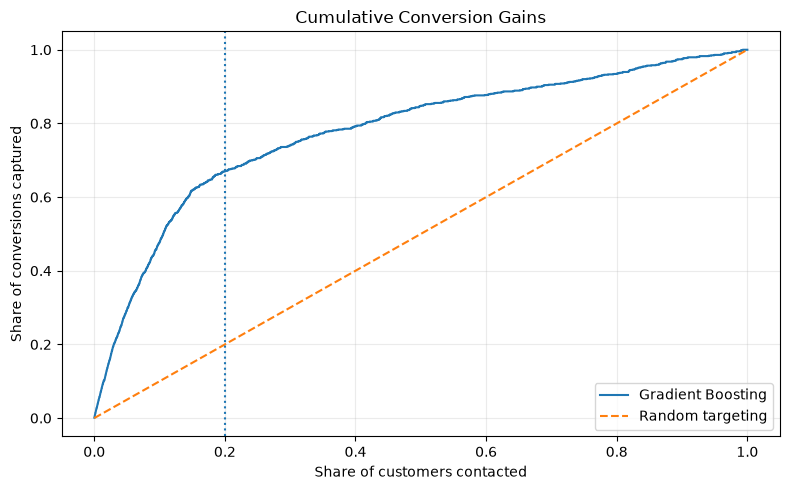

In [17]:
# Cumulative conversion gains

def cumulative_gains(y_true, probabilities):
    order = np.argsort(probabilities)[::-1]
    y_sorted = np.asarray(y_true)[order]

    cumulative_conversions = np.cumsum(y_sorted)
    total_conversions = y_sorted.sum()

    population_fraction = (
        np.arange(1, len(y_sorted) + 1) / len(y_sorted)
    )

    conversion_capture = (
        cumulative_conversions / total_conversions
    )

    return population_fraction, conversion_capture


gb_population, gb_capture = cumulative_gains(
    y_test,
    improved_prob
)

plt.figure(figsize=(8, 5))
plt.plot(
    gb_population,
    gb_capture,
    label="Gradient Boosting"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random targeting"
)

plt.axvline(
    TOP_FRACTION,
    linestyle=":"
)

plt.xlabel("Share of customers contacted")
plt.ylabel("Share of conversions captured")
plt.title("Cumulative Conversion Gains")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.savefig(
    "outputs_cumulative_gains.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [18]:
# Historical campaign saturation analysis

saturation = (
    raw_for_audit
    .groupby("campaign")["target"]
    .agg(
        contacts="size",
        conversions="sum",
        conversion_rate="mean"
    )
    .reset_index()
)

print("CAMPAIGN SATURATION")
print(
    saturation.to_string(
        index=False,
        formatters={
            "conversion_rate": lambda x: f"{x:.2%}"
        }
    )
)

CAMPAIGN SATURATION
 campaign  contacts  conversions conversion_rate
        1     17642         2300          13.04%
        2     10570         1211          11.46%
        3      5341          574          10.75%
        4      2651          249           9.39%
        5      1599          120           7.50%
        6       979           75           7.66%
        7       629           38           6.04%
        8       400           17           4.25%
        9       283           17           6.01%
       10       225           12           5.33%
       11       177           12           6.78%
       12       125            3           2.40%
       13        92            4           4.35%
       14        69            1           1.45%
       15        51            2           3.92%
       16        51            0           0.00%
       17        58            4           6.90%
       18        33            0           0.00%
       19        26            0           0.00%


In [20]:
# Subgroup selection audit for the Top-20% policy

audit_df = raw_for_audit.loc[
    X_test.index,
    ["age", "marital", "education", "target"]
].copy()

audit_df["predicted_probability"] = improved_prob

n_top = int(len(audit_df) * TOP_FRACTION)

top_indices = (
    audit_df["predicted_probability"]
    .nlargest(n_top)
    .index
)

audit_df["selected"] = audit_df.index.isin(top_indices)

# Create practical age groups
audit_df["age_group"] = pd.cut(
    audit_df["age"],
    bins=[0, 29, 44, 59, np.inf],
    labels=["<30", "30-44", "45-59", "60+"]
)


def make_audit(data, variable):
    result = (
        data.groupby(variable, observed=True)
        .agg(
            sample_size=("target", "size"),
            actual_conversion_rate=("target", "mean"),
            selection_rate=("selected", "mean")
        )
        .reset_index()
    )

    result.insert(0, "variable", variable)
    result = result.rename(columns={variable: "group"})

    return result


fairness_audit = pd.concat(
    [
        make_audit(audit_df, "age_group"),
        make_audit(audit_df, "marital"),
        make_audit(audit_df, "education")
    ],
    ignore_index=True
)

print("SUBGROUP SELECTION AUDIT")
print(
    fairness_audit.to_string(
        index=False,
        formatters={
            "actual_conversion_rate": lambda x: f"{x:.2%}",
            "selection_rate": lambda x: f"{x:.2%}"
        }
    )
)

SUBGROUP SELECTION AUDIT
 variable               group  sample_size actual_conversion_rate selection_rate
age_group                 <30         1095                 15.25%         34.70%
age_group               30-44         4555                  9.97%         15.74%
age_group               45-59         2344                  9.00%         14.76%
age_group                 60+          244                 39.34%         83.61%
  marital            divorced          937                 11.21%         18.04%
  marital             married         4975                 10.29%         17.07%
  marital              single         2311                 13.41%         27.09%
  marital             unknown           15                  6.67%         20.00%
education            basic.4y          854                  9.84%         15.46%
education            basic.6y          427                  7.49%         11.48%
education            basic.9y         1219                  8.53%         11.98%
edu

In [21]:
# Save reproducible analytical outputs

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

model_metrics.to_csv(
    output_dir / "model_metrics.csv",
    index=False
)

importance_df.to_csv(
    output_dir / "permutation_importance.csv",
    index=False
)

fairness_audit.to_csv(
    output_dir / "fairness_subgroup_audit.csv",
    index=False
)

saturation.to_csv(
    output_dir / "campaign_saturation.csv",
    index=False
)

financial_sensitivity = pd.DataFrame({
    "scenario": [
        "Baseline €250",
        "Lower campaign value €200",
        "100 bps illustrative stress"
    ],
    "mass_outreach_profit": [
        legacy_profit,
        mass_profit_200,
        np.nan
    ],
    "top20_profit": [
        gb_profit,
        top20_profit_200,
        stressed_profit
    ]
})

financial_sensitivity.to_csv(
    output_dir / "financial_sensitivity.csv",
    index=False
)

print("OUTPUT FILES SAVED")
for file in sorted(output_dir.glob("*.csv")):
    print(file)

OUTPUT FILES SAVED
outputs\campaign_saturation.csv
outputs\fairness_subgroup_audit.csv
outputs\financial_sensitivity.csv
outputs\model_metrics.csv
outputs\permutation_feature_families.csv
outputs\permutation_importance.csv


## 2. Decision Summary

### Recommended policy

Use the Gradient Boosting model to rank customers by predicted response probability and target the highest-scoring **20%**.

The model improves on the Logistic Regression baseline across ROC-AUC, Brier score, Precision@20%, Recall@20%, and Lift@20%.

### Business case

Under the illustrative assumptions of €15 per call and €250 campaign value, the Top-20% policy produces higher estimated campaign profit than mass outreach.

The policy also remains profitable under the €200 campaign-value scenario and under the illustrative 100 bps interest-rate stress.

### Governance

The model should be deployed as a **ranking aid**, not an automatic customer-decision system. Selection rates should be monitored across demographic subgroups, and the pilot should use a randomized control group to measure incremental conversion.

Historical campaign saturation is treated as a descriptive association rather than proof of causal contact fatigue.

### Pilot recommendation

Run a randomized pilot comparing model-based Top-20% targeting with the existing outreach policy. The primary business KPI should be **incremental conversion lift versus control**, with Precision@20% and campaign economics monitored as supporting metrics.